# Exploratory Data Analysis — HarmonyMix

This notebook looks at the two raw inputs behind the recommenders — the track
catalogue (`data/raw/tracks.csv`) and the listening history (`data/raw/playlists.csv`)
— and answers the questions that actually shaped the preprocessing and modelling
decisions in `src/`:

1. Is the data clean enough to use as-is? (missing values, duplicates, outliers)
2. What do the audio features look like, individually and against each other?
3. How much listening-history coverage does the catalogue actually have, and what
   does that imply for collaborative filtering?
4. What does the final feature matrix that content-based similarity runs on
   actually look like?

Every chart below is followed by a short "Observation" — the point of the chart,
not just the chart. Further discussion is summarized in the project README.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_columns', 25)

tracks = pd.read_csv('../data/raw/tracks.csv')
tracks.shape

(50683, 21)

## 1. First look at the track catalogue

In [2]:
tracks.head(3)

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,0.918,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,0.892,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,0.826,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4


In [3]:
tracks.dtypes

track_id                   str
name                       str
artist                     str
spotify_preview_url        str
spotify_id                 str
tags                       str
genre                      str
year                     int64
duration_ms              int64
danceability           float64
energy                 float64
key                      int64
loudness               float64
mode                     int64
speechiness            float64
acousticness           float64
instrumentalness       float64
liveness               float64
valence                float64
tempo                  float64
time_signature           int64
dtype: object

**Observation:** 21 columns — identifiers/text metadata (`track_id`, `name`,
`artist`, `spotify_id`, `spotify_preview_url`, `tags`, `genre`), one release year,
and 11 numeric Spotify audio features on very different natural scales
(`loudness` is roughly -60..+4 dB, `tempo` is roughly 0..240 BPM, most of the rest
are already 0..1). That scale mismatch is exactly why `preprocess.py` scales
every numeric column before anything gets compared — see Section 5.

## 2. Missing values

A recommender can't compare a `NaN`, so this decides what preprocessing has to
handle — and, in `genre`'s case, why a whole column got left out of the model.

In [4]:
missing = tracks.isna().sum()
missing_pct = (missing / len(tracks) * 100).round(1)
pd.DataFrame({'missing': missing, 'pct': missing_pct}).query('missing > 0')

,missing,pct
tags,1127,2.2
genre,28335,55.9


**Observation:** `genre` is missing on **55.9%** of rows — more absent than
present. That's why `content_based.py` drops `genre` from the columns it fits on
and leans on `tags` instead (missing on only 2.2% of rows, filled with the literal
string `"no_tags"` in `clean_and_prepare_dataset`). Using a feature that's missing
on more than half the catalogue would have meant either throwing away half the
data or building a model mostly out of an imputed placeholder — `tags` is simply
the more complete signal for genre-like information. No other column has missing
values, so there's nothing else to impute.

## 3. Duplicate tracks

`clean_and_prepare_dataset` drops duplicates on `(spotify_id, year, duration_ms)`,
not on `spotify_id` alone. Here's why that specific key was chosen.

In [5]:
exact_dupes = tracks.duplicated(subset=['spotify_id', 'year', 'duration_ms']).sum()
same_spotify_id = tracks.duplicated(subset=['spotify_id'], keep=False)
print(f"Rows that are exact (spotify_id, year, duration_ms) duplicates: {exact_dupes}")
print(f"Rows that merely share a spotify_id: {same_spotify_id.sum()}")

tracks[same_spotify_id].sort_values('spotify_id')[['name', 'artist', 'spotify_id', 'year', 'duration_ms']].head(10)

Rows that are exact (spotify_id, year, duration_ms) duplicates: 9
Rows that merely share a spotify_id: 18


,name,artist,spotify_id,year,duration_ms
15326,Adagio For Strings,Samuel Barber,00otCiz9kUb3Vg7LPKNCZG,2014,431412
21570,"Adagio for Strings, Op. 11",Samuel Barber,00otCiz9kUb3Vg7LPKNCZG,2014,431412
14861,How Do You Want It,2Pac,02VsIBmSkhc7uHNyPViZR3,2011,289000
14981,How Do U Want It,2Pac,02VsIBmSkhc7uHNyPViZR3,2011,289000
37040,Je pense à toi,Amadou & Mariam,09jsAIZF9ThihIzdrw4KAS,2005,316880
49162,Je Pense A Toi,Amadou & Mariam,09jsAIZF9ThihIzdrw4KAS,2005,316880
13427,Too Much Too Young,The Specials,0ndKJL8gA4zLl317M7vndn,2012,116160
46512,Too Much Too Young (Live),The Specials,0ndKJL8gA4zLl317M7vndn,2012,116160
1684,There There,Radiohead,0thdzbW0cRKCx12VbBRB6T,2008,323600
2983,"There, There",Radiohead,0thdzbW0cRKCx12VbBRB6T,2008,323600


**Observation:** Every pair that shares a `spotify_id` also matches on `year`
*and* `duration_ms` — they're the same recording with a slightly different title
string in the source data (`"There There"` vs. `"There, There"`, an encoding
artifact in `"Je pense à toi"`, `"hHallmark"` vs. `"Hallmark"`). Deduplicating on
`spotify_id` alone would give the same result here, but it would be the wrong rule
in general — a live version, a remaster, or a re-release can legitimately reuse a
`spotify_id` with a different `year`/`duration_ms`, and those are different catalogue
entries an interviewer might reasonably ask the model to tell apart. Requiring all
three columns to match is the safer definition of "duplicate."


## 4. Numerical summary and outliers

`describe()` first, then a closer look at the tails, because a few rows with
implausible values can distort a similarity score just as much as a missing one.

In [6]:
tracks[['year', 'duration_ms', 'tempo', 'loudness', 'danceability', 'energy',
        'acousticness', 'valence']].describe().round(3)

,year,duration_ms,tempo,loudness,danceability,energy,acousticness,valence
count,50683.000,50683.000,50683.000,50683.000,50683.000,50683.000,50683.000,50683.000
mean,2004.017,251155.106,123.508,-8.291,0.494,0.686,0.214,0.433
std,8.860,107585.956,29.621,4.548,0.179,0.252,0.303,0.259
min,1900.000,1439.000,0.000,-60.000,0.000,0.000,0.000,0.000
25%,2001.000,192733.000,100.683,-10.375,0.364,0.514,0.001,0.214
50%,2006.000,234933.000,121.989,-7.200,0.497,0.744,0.040,0.405
75%,2009.000,288193.000,141.639,-5.089,0.621,0.905,0.340,0.634
max,2022.000,3816373.000,238.895,3.642,0.986,1.000,0.996,0.993


Shortest track: 0.02 min | Longest track: 63.6 min
Tracks under 30s: 2
Tracks over 15 min: 116
Rows with tempo == 0 (undetected tempo): 10


C:\Users\NISHANTH\AppData\Local\Temp\ipykernel_9480\2340094680.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(minutes, vert=False)
C:\Users\NISHANTH\AppData\Local\Temp\ipykernel_9480\2340094680.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(tracks['loudness'], vert=False)


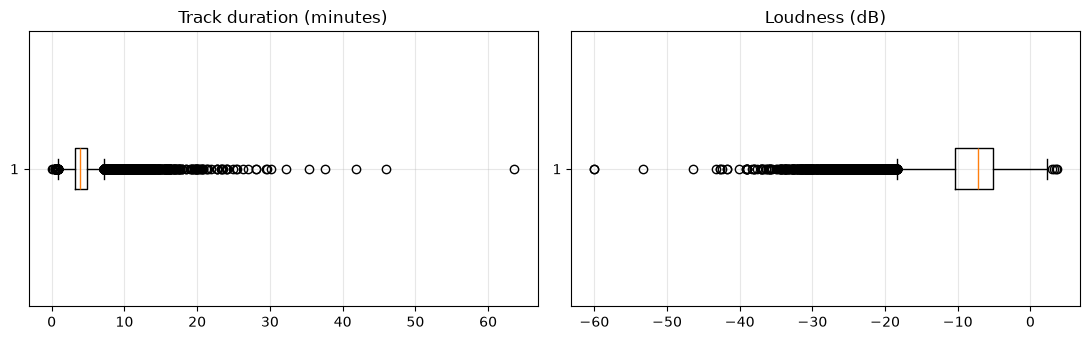

In [7]:
minutes = tracks['duration_ms'] / 60_000
print(f"Shortest track: {minutes.min():.2f} min | Longest track: {minutes.max():.1f} min")
print(f"Tracks under 30s: {(tracks['duration_ms'] < 30_000).sum()}")
print(f"Tracks over 15 min: {(minutes > 15).sum()}")
print(f"Rows with tempo == 0 (undetected tempo): {(tracks['tempo'] == 0).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
# vert=False (not orientation=) for compatibility with matplotlib>=3.4.0, the
# floor pinned in requirements.txt — `orientation` isn't available that far back.
axes[0].boxplot(minutes, vert=False)
axes[0].set_title('Track duration (minutes)')
axes[1].boxplot(tracks['loudness'], vert=False)
axes[1].set_title('Loudness (dB)')
plt.tight_layout()
plt.show()

**Observation:** A handful of rows are clearly data-quality edge cases rather
than real songs — sub-30-second clips, a ~64-minute "track", and 10 rows where
`tempo` is exactly 0 (a tempo detector reporting nothing rather than a genuine
0 BPM song). None of these crash the pipeline (`MinMaxScaler`/`StandardScaler`
handle them like any other value) and at 10-20 rows out of 50,683 they aren't
worth adding filtering logic for — but they're the reason a production version of
this pipeline would want a `0 < duration_ms < some_ceiling` and `tempo > 0` sanity
filter before fitting. Recorded here rather than silently fixed, per known limitations.

## 5. Audio feature distributions

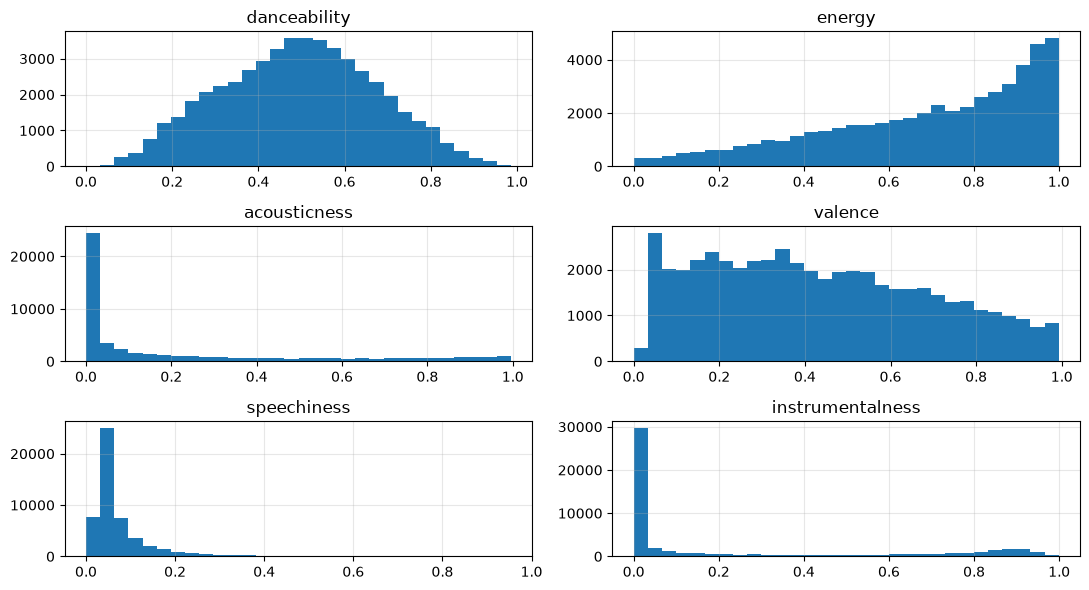

In [ ]:
feature_cols = ['danceability', 'energy', 'acousticness', 'valence', 'speechiness', 'instrumentalness']
tracks[feature_cols].hist(bins=30, figsize=(11, 6))
plt.tight_layout()
plt.show()

**Observation:** `danceability`, `energy` and `valence` are roughly bell-shaped
and use their full 0-1 range — genuinely discriminating features. `acousticness`,
`speechiness` and `instrumentalness` are heavily right-skewed with a wall of mass
near 0: most tracks in this catalogue are electric/produced, use mostly sung vocals,
and are not instrumental. That's expected for a mainstream-leaning catalogue, and it
means those three features mostly do their discriminating work on the minority of
tracks where they're *not* near zero (acoustic sets, spoken-word/rap, instrumentals) —
exactly the tracks where you'd want them to matter most.

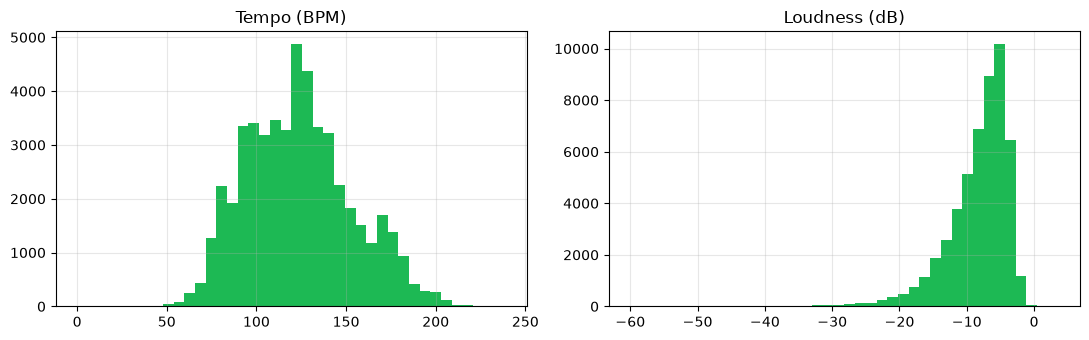

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(tracks['tempo'], bins=40, color='#1DB954')
ax[0].set_title('Tempo (BPM)')
ax[1].hist(tracks['loudness'], bins=40, color='#1DB954')
ax[1].set_title('Loudness (dB)')
plt.tight_layout()
plt.show()

**Observation:** `tempo` clusters around common song tempos (~90-140 BPM) with
small secondary bumps near double/half-time values, which is a known artifact of
tempo-detection algorithms rather than a data error. `loudness` is left-skewed and
tight — most commercial masters sit around -5 to -8 dB, with a long, thin tail down
to -60 dB (quiet/ambient tracks). Both are on scales nothing else in the dataset
shares, reinforcing why `StandardScaler` is applied to them specifically.

## 6. Categorical summary — genre and artist

Unique non-null genres: 15


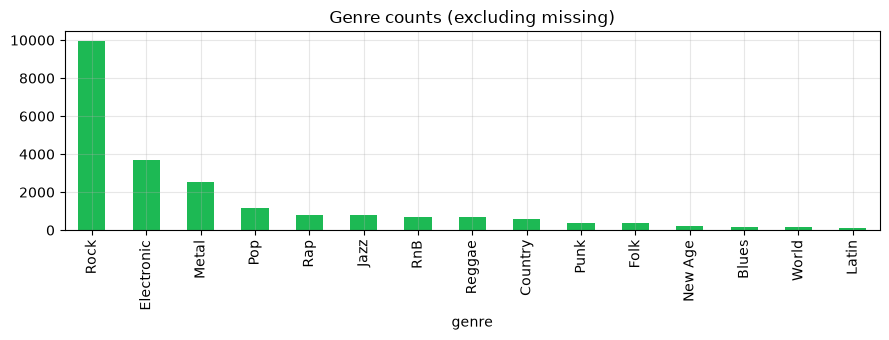

In [10]:
genre_counts = tracks['genre'].value_counts()
print(f"Unique non-null genres: {tracks['genre'].nunique()}")
genre_counts.plot(kind='bar', figsize=(9, 3.5), color='#1DB954')
plt.title('Genre counts (excluding missing)')
plt.tight_layout()
plt.show()

**Observation:** Rock dominates the labelled subset (about 40% of the rows
that *have* a genre), with Electronic and Metal next. Given genre is missing on
56% of rows to begin with, this distribution should be read as "what the labelled
minority looks like," not as a claim about the whole catalogue — another reason
`tags` (far more complete, and multi-valued rather than single-label) is the
feature actually used for content similarity.

Unique artists: 8,317 across 50,683 tracks


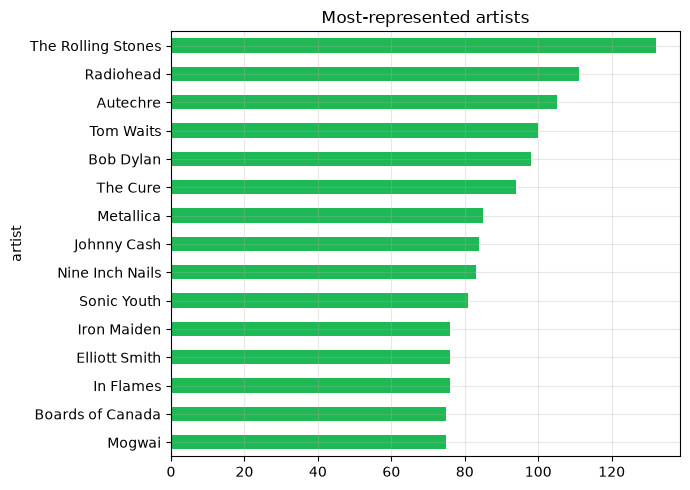

In [11]:
print(f"Unique artists: {tracks['artist'].nunique():,} across {len(tracks):,} tracks")
top_artists = tracks['artist'].value_counts().head(15)
top_artists.plot(kind='barh', figsize=(7, 5), color='#1DB954')
plt.gca().invert_yaxis()
plt.title('Most-represented artists')
plt.tight_layout()
plt.show()

**Observation:** With 8,317 distinct artists, one-hot-encoding every artist
would add over 8,000 columns dominated by artists with a single track. That's why
`get_preprocessor_transformer` caps the artist encoder at `max_categories=200`
(`OneHotEncoder(max_categories=200)`) — the long tail of one-off artists collapses
into an "infrequent" bucket instead of each getting its own dimension.

## 7. How the audio features relate to each other

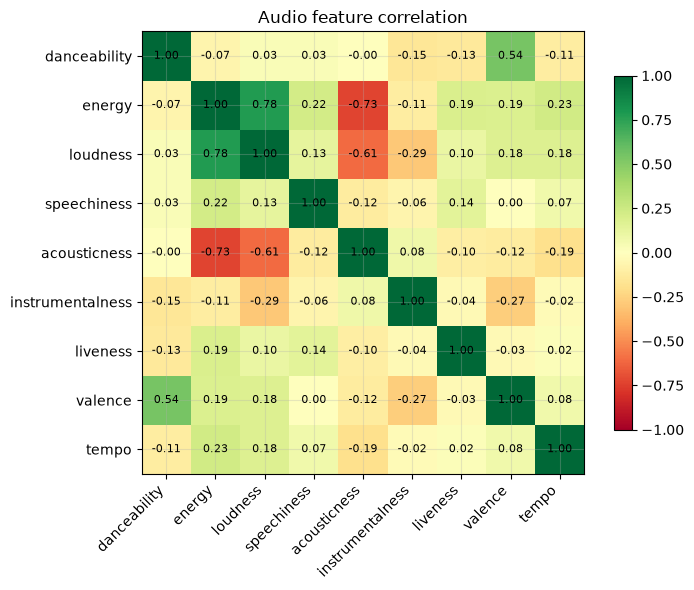

In [12]:
corr_cols = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
             'instrumentalness', 'liveness', 'valence', 'tempo']
corr = tracks[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=45, ha='right')
ax.set_yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Audio feature correlation')
plt.tight_layout()
plt.show()

**Observation:** The strongest relationships all make musical sense —
`energy` and `loudness` are strongly positive (**+0.78**: louder mixes read as more
energetic), `acousticness` and `energy` are strongly negative (**-0.73**: acoustic
tracks are produced quieter and less "driven"), and `danceability` and `valence`
are moderately positive (**+0.54**: happier-sounding tracks tend to be more
danceable). None of these pairs are correlated enough (no `|r| > 0.8`) to call
redundant, so keeping all nine as separate similarity dimensions is reasonable —
but `energy` and `loudness` are close enough that a track's "energy" in this
feature set is partly just "how it was mixed," worth knowing when explaining a
recommendation that leans on those two.

## 8. What the content-based feature matrix is actually made of

Cosine similarity runs on the *output* of `get_preprocessor_transformer`, not on
the raw columns above. It's worth seeing how that matrix is actually composed,
since it isn't just "9 audio features".

Total feature-matrix width: 315 columns


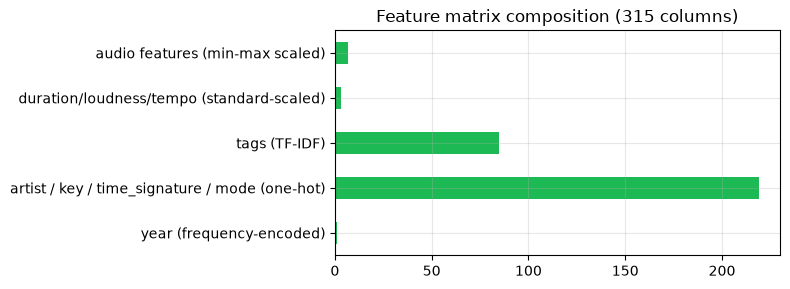

In [13]:
import sys
sys.path.append('..')
from src.preprocessing.preprocess import clean_and_prepare_dataset, get_preprocessor_transformer

clean = clean_and_prepare_dataset(tracks)
fit_df = clean.drop(columns=[c for c in ['track_id', 'name', 'spotify_id', 'genre', 'spotify_preview_url'] if c in clean.columns])
transformer = get_preprocessor_transformer(fit_df)
matrix = transformer.fit_transform(fit_df)

widths = {'year (frequency-encoded)': 1, 'artist / key / time_signature / mode (one-hot)': 219,
          'tags (TF-IDF)': 85, 'duration/loudness/tempo (standard-scaled)': 3,
          'audio features (min-max scaled)': 7}
print(f"Total feature-matrix width: {matrix.shape[1]} columns")
pd.Series(widths).plot(kind='barh', figsize=(8, 3), color='#1DB954')
plt.title('Feature matrix composition (315 columns)')
plt.tight_layout()
plt.show()

**Observation:** Only 10 of the 315 columns (3%) are the numeric audio
features people usually mean by "sounds similar" — 219 columns (70%) are the
one-hot-encoded `artist`/`key`/`time_signature`/`mode` block, and 85 (27%) are the
`tags` TF-IDF vector. In practice this means content-based similarity is driven
at least as much by *shared artist and shared tags* as by audio DNA — which is
worth knowing before claiming "the model recommends songs that sound alike": it
partly recommends songs that share a label with the query track. This isn't a bug
(one-hot columns and min-max-scaled columns are both roughly unit-scale, so no
single block mathematically dominates the way the unscaled `year` bug used to),
but it is a real characteristic worth being able to explain, and a natural
ablation to try next (compare rankings with the artist one-hot block removed).


## 9. Listening-history coverage and the cold-start question

`data/raw/playlists.csv` (~575 MB, `track_id` / `user_id` / `playcount`) is what
the collaborative recommender learns from. The key EDA question here isn't "what
does it look like" so much as "how much of the track catalogue does it actually
cover" — because that number is exactly what determines how often the hybrid
engine has to fall back to content-only scoring.

Catalogue tracks:                    50,683
Tracks with >=1 listening interaction: 30,459
Tracks with ZERO interactions (cold-start): 20,224  (39.9%)
Interaction rows referencing a track not in the catalogue: 0


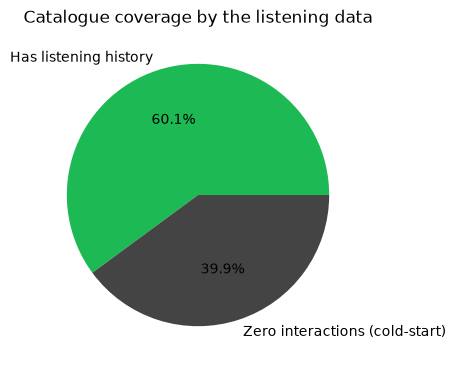

In [14]:
playlist_tracks = pd.read_csv('../data/raw/playlists.csv', usecols=['track_id'])
catalogue_ids = set(tracks['track_id'])
history_ids = set(playlist_tracks['track_id'].unique())

covered = catalogue_ids & history_ids
cold_start = catalogue_ids - history_ids

print(f"Catalogue tracks:                    {len(catalogue_ids):,}")
print(f"Tracks with >=1 listening interaction: {len(covered):,}")
print(f"Tracks with ZERO interactions (cold-start): {len(cold_start):,}  ({len(cold_start)/len(catalogue_ids):.1%})")
print(f"Interaction rows referencing a track not in the catalogue: {len(history_ids - catalogue_ids)}")

plt.figure(figsize=(4.5, 4.5))
plt.pie([len(covered), len(cold_start)], labels=['Has listening history', 'Zero interactions (cold-start)'],
        autopct='%1.1f%%', colors=['#1DB954', '#444444'])
plt.title('Catalogue coverage by the listening data')
plt.tight_layout()
plt.show()

**Observation:** **40% of the 50,683-track catalogue has no listening history
at all.** For those ~20,224 tracks, `CollaborativeFilteringRecommender.get_recommendations`
returns an empty DataFrame by construction (`track_id not in self.track_to_idx`),
and the hybrid engine's `fillna(0.0)` on the merge means their hybrid score
collapses to pure content score. This is the concrete, measured version of the
cold-start limitation — not a hypothetical edge case, but something that would
happen for 2 out of every 5 tracks a user might pick, and the main reason the
hybrid design (rather than collaborative alone) exists. Every interaction row
does reference a real catalogue track, so there's no orphaned-ID data-quality
issue on that side.

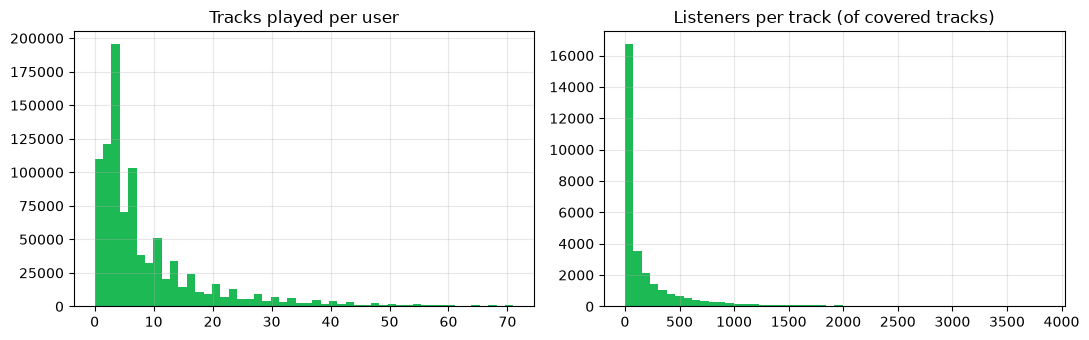

Users: 962,037 | median tracks/user: 5 | mean: 10.1 | max: 784
Median listeners for a covered track: 57 | mean: 318.8


In [15]:
user_track_counts = playlist_tracks.groupby(playlist_tracks['track_id']).size()
per_user = pd.read_csv('../data/raw/playlists.csv', usecols=['user_id']).groupby('user_id').size()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(per_user, bins=50, range=(0, per_user.quantile(0.99)), color='#1DB954')
ax[0].set_title('Tracks played per user')
ax[1].hist(user_track_counts, bins=50, range=(0, user_track_counts.quantile(0.99)), color='#1DB954')
ax[1].set_title('Listeners per track (of covered tracks)')
plt.tight_layout()
plt.show()

print(f"Users: {per_user.shape[0]:,} | median tracks/user: {per_user.median():.0f} | mean: {per_user.mean():.1f} | max: {per_user.max()}")
print(f"Median listeners for a covered track: {user_track_counts.median():.0f} | mean: {user_track_counts.mean():.1f}")

**Observation:** Both distributions are heavily right-skewed (typical of
implicit-feedback data) — half of users have 5 or fewer tracks in their history,
while a small number have played hundreds. This is exactly the kind of sparse,
long-tailed interaction pattern that makes a co-occurrence matrix a defensible,
simple starting point, while also explaining why a learned latent-factor model
(SVD/ALS) is listed as a natural next step — those methods are specifically
built to generalize better on sparse, skewed interactions than raw
co-occurrence counts.

## 10. Popularity

The app and tests reference an optional `popularity` column (`if 'popularity' in
tracks_df.columns`, used for the default song list and the track-card progress
bar), but **the real `tracks.csv` has no `popularity` column** — it only appears
in the small synthetic fallback dataset `app/app.py` generates when no data files
are present. So there's no real popularity distribution to plot here; showing one
would mean fabricating a column that doesn't exist in the actual dataset. The
closest real proxy available is listening-history frequency, which is what
Section 9's "listeners per track" chart already shows.

## 11. Summary — how this EDA shaped the project

| Finding | Consequence |
|---|---|
| `genre` missing on 55.9% of rows | Dropped from the model; `tags` (2.2% missing) used instead |
| 9 exact `(spotify_id, year, duration_ms)` duplicates, all title-string variants | Dedup key chosen to be that triple, not `spotify_id` alone, so legitimate re-releases aren't merged |
| `year`/`tempo`/`loudness`/`duration_ms` on very different scales than the 0-1 audio features | Frequency-encoding (`year`) + `StandardScaler`/`MinMaxScaler` applied before any similarity is computed |
| 8,317 artists, long-tailed | Artist one-hot encoding capped at `max_categories=200` |
| Only 10/315 feature-matrix columns are raw audio features; 70% are artist one-hot | Content-based similarity is understood (and can be explained in an interview) as "audio feel + shared artist/tags," not audio features alone |
| 40% of the catalogue has zero listening interactions | Quantifies exactly why the hybrid engine's content-score fallback matters, not just why it exists |
| `tempo == 0` for 10 rows, sub-30s and 60+ minute outlier tracks | Noted as a data-quality edge case for a future filtering step; doesn't crash the current pipeline |
| No `popularity` column in the real data | Not fabricated for this notebook; the app treats it as optional for exactly this reason |

No feature engineering changed as a result of this notebook alone — the one
genuine bug this kind of investigation *did* surface (an unscaled `year` column
dominating content-based cosine similarity) was fixed directly in
`src/preprocessing/preprocess.py`.